<center><h1>Лабораторная работа № 6</h1></center>

---

## **Тема:** <u>Алгоритмы кластеризации</u>.

Для работы используйте <u>данные подходящие для кластеризации</u> на свой выбор.

Еще для кластеризации **подходят датасеты для многоклассовой классификации**, только
нужно удалить столбец с метками классов, чтобы имитировать обучение без учителя.

Примеры есть в папке примеров на дискстейшене и еще <span style="color: red; ">!</span> рекомендую смотреть примеры
на сайте [www.kaggle.com](https://www.kaggle.com/).  

---

1. Из датасета выберите наиболее важные параметры, характеризующие цель исследования и сформируйте из них матрицу X.

In [4]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
X = df[
    [
        "Age",
        "Annual Income (k$)",
        "Spending Score (1-100)"
    ]
]

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


2. Проверьте Х на пропуски и закодируйте категориальные данные, если это необходимо.

In [10]:
X.isnull().sum()

Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

3. Нормализуйте значения в матрице Х функцией MinMaxScaler().

In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

4. C помощью метода локтя определите оптимальное количество кластеров и разделите данные на кластеры методом **K-means**.


In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

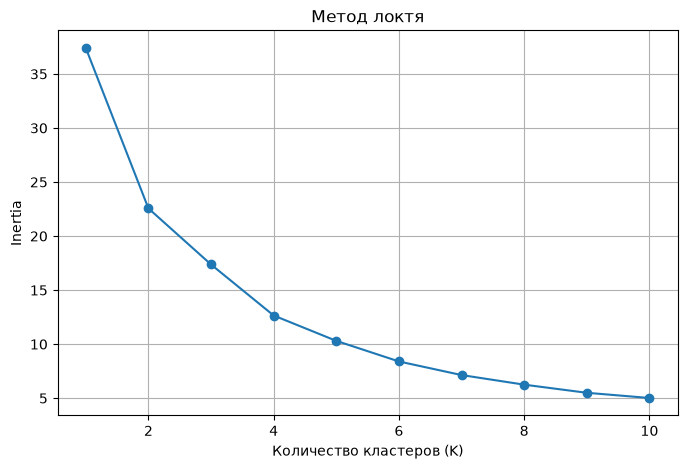

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inertia,
    marker='o'
)

plt.xlabel('Количество кластеров (K)')
plt.ylabel('Inertia')
plt.title('Метод локтя')

plt.grid()
plt.show()

In [17]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 3)","[[0.2

In [18]:
clusters = kmeans.labels_

clusters

array([1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 2, 1,
       2, 2, 1, 1, 2, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 1, 2, 2, 1, 2, 2, 1,
       1, 2, 2, 1, 2, 2, 1, 1, 2, 1, 2, 1, 1, 2, 2, 1, 2, 1, 2, 2, 2, 2,
       2, 1, 3, 1, 1, 1, 2, 2, 2, 2, 1, 3, 0, 0, 3, 0, 3, 0, 2, 0, 3, 0,
       3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0,
       3, 0, 3, 0, 3, 0, 2, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0,
       3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0,
       3, 0], dtype=int32)

In [19]:
df['Cluster'] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,1
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


In [20]:
df['Cluster'].value_counts().sort_index()

Cluster
0    40
1    57
2    65
3    38
Name: count, dtype: int64

5. Визуализируйте результаты кластеризации, выбрав для визуализации два параметра из матрицы Х.

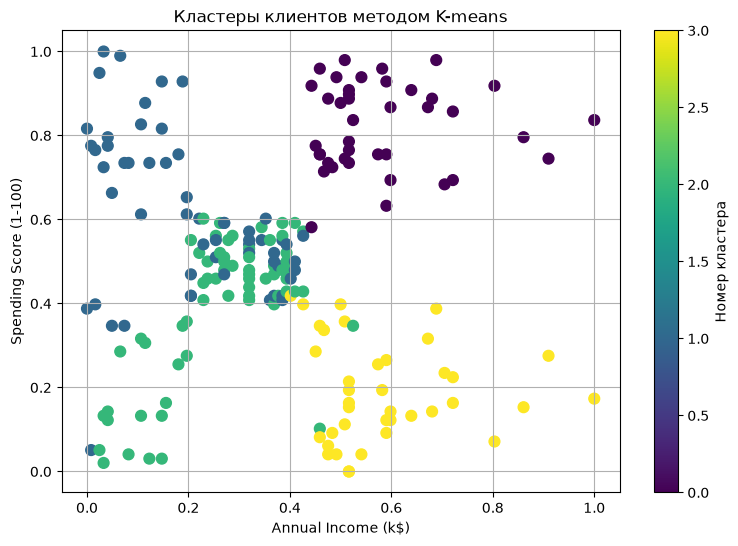

In [22]:
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

X_scaled.head()
plt.figure(figsize=(9, 6))

plt.scatter(
    X_scaled["Annual Income (k$)"],
    X_scaled["Spending Score (1-100)"],
    c=clusters,
    cmap="viridis",
    s=60
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Кластеры клиентов методом K-means")

plt.colorbar(label="Номер кластера")
plt.grid()
plt.show()

6. Разделите данные на кластеры **методом иерархической кластеризации**, выберите с помощью дендрограммы оптимальное количество кластеров.


In [24]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X_scaled, method='ward')

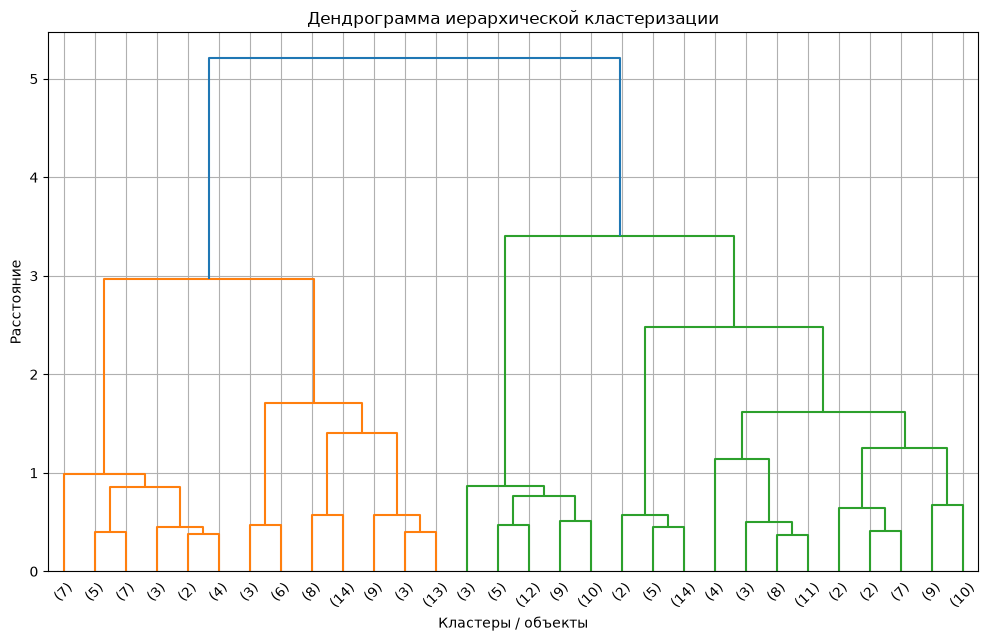

In [25]:
plt.figure(figsize=(12, 7))

dendrogram(
    Z,
    truncate_mode='lastp',
    p=30
)

plt.title('Дендрограмма иерархической кластеризации')
plt.xlabel('Кластеры / объекты')
plt.ylabel('Расстояние')

plt.grid()
plt.show()

In [26]:
Z = linkage(X_scaled, method='ward')

In [27]:
from scipy.cluster.hierarchy import fcluster

hierarchical_clusters = fcluster(
    Z,
    t=2,
    criterion='maxclust'
)

In [28]:
pd.Series(hierarchical_clusters).value_counts().sort_index()

1     84
2    116
Name: count, dtype: int64

In [29]:
df['Hierarchical_Cluster'] = hierarchical_clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Hierarchical_Cluster
0,1,Male,19,15,39,1,2
1,2,Male,21,15,81,1,2
2,3,Female,20,16,6,1,2
3,4,Female,23,16,77,1,2
4,5,Female,31,17,40,1,2


7. Визуализируйте результаты кластеризации методом иерархической кластеризации.


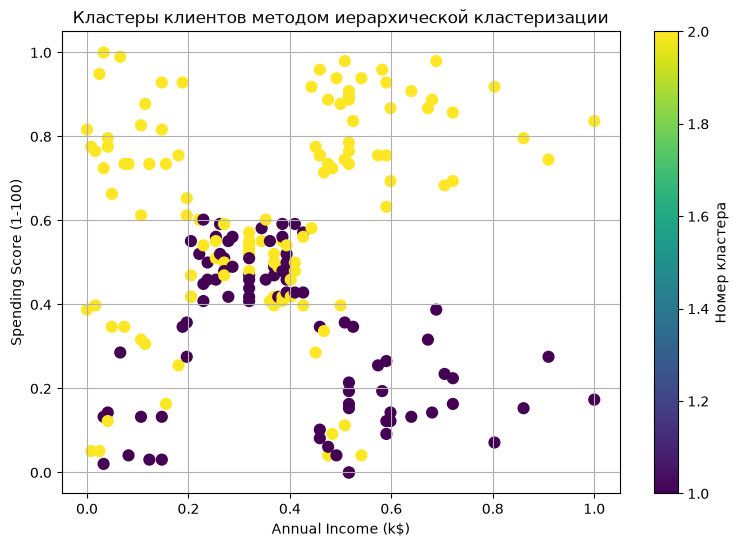

In [30]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_scaled["Annual Income (k$)"],
    X_scaled["Spending Score (1-100)"],
    c=hierarchical_clusters,
    cmap="viridis",
    s=60
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Кластеры клиентов методом иерархической кластеризации")

plt.colorbar(label="Номер кластера")
plt.grid()
plt.show()

8. Оцените качество кластеризации методами K-means и иерархической кластеризации, рассчитав пару метрик качества кластеризации (модуль **sklearn.metrics**). Например, силуэт для выборки **silhouette_score()** и др. *Сделайте вывод о наилучшем методе для ваших данных. Оцените с помощью силуэта качество кластеров.*

In [31]:
from sklearn.metrics import silhouette_score

silhouette_kmeans = silhouette_score(
    X_scaled,
    clusters
)

silhouette_hierarchical = silhouette_score(
    X_scaled,
    hierarchical_clusters
)

print("Silhouette Score K-means:", silhouette_kmeans)
print(
    "Silhouette Score Hierarchical:",
    silhouette_hierarchical
)

Silhouette Score K-means: 0.392319202055722
Silhouette Score Hierarchical: 0.33752602297520423


In [32]:
from sklearn.metrics import calinski_harabasz_score

ch_kmeans = calinski_harabasz_score(
    X_scaled,
    clusters
)

ch_hierarchical = calinski_harabasz_score(
    X_scaled,
    hierarchical_clusters
)

print("Calinski-Harabasz K-means:", ch_kmeans)
print(
    "Calinski-Harabasz Hierarchical:",
    ch_hierarchical
)

Calinski-Harabasz K-means: 127.82934910391882
Calinski-Harabasz Hierarchical: 112.84248712685314


9. Из датасета выберите любой конкретный объект и визуализируйте этот объект в виде точки отличного цвета и размера на графике кластеров (пример на рисунке, точка пурпурного цвета). Можно увидеть в каком кластере находится выбранный объект.  
<img align="right" src="img/Screenshot_2026-09-27-133702.png">

In [33]:
customer_index = 0

selected_customer = X_scaled.iloc[customer_index]

print("Индекс объекта:", customer_index)
print("Возраст:", X.iloc[customer_index]["Age"])
print("Доход:", X.iloc[customer_index]["Annual Income (k$)"])
print(
    "Spending Score:",
    X.iloc[customer_index]["Spending Score (1-100)"]
)
print("Кластер:", clusters[customer_index])

Индекс объекта: 0
Возраст: 19
Доход: 15
Spending Score: 39
Кластер: 1


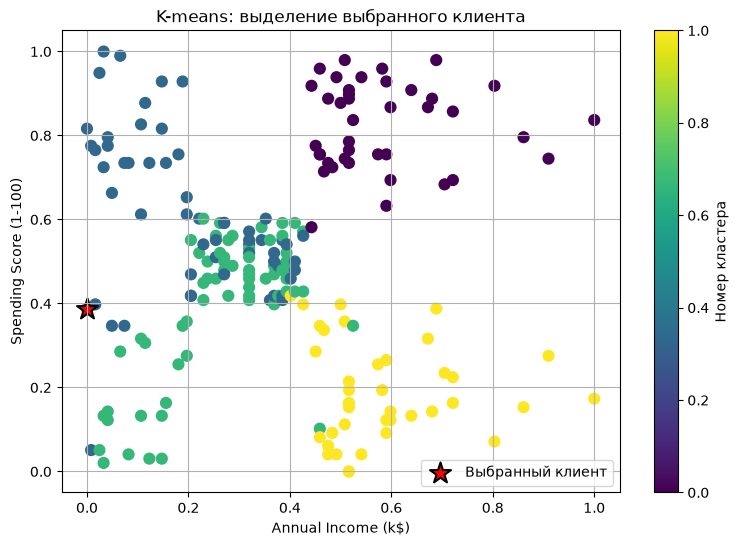

In [34]:
plt.figure(figsize=(9, 6))

# Все клиенты
plt.scatter(
    X_scaled["Annual Income (k$)"],
    X_scaled["Spending Score (1-100)"],
    c=clusters,
    cmap="viridis",
    s=60
)

# Выбранный клиент
plt.scatter(
    X_scaled.iloc[customer_index]["Annual Income (k$)"],
    X_scaled.iloc[customer_index]["Spending Score (1-100)"],
    color="red",
    s=250,
    marker="*",
    edgecolors="black",
    linewidths=1.5,
    label="Выбранный клиент"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-means: выделение выбранного клиента")

plt.colorbar(label="Номер кластера")
plt.legend()
plt.grid()
plt.show()

---
### Вопросы:

#### 1. Что решают задачи кластеризации в машинном обучении?

**Кластеризация** — это задача машинного обучения без учителя, при которой объекты автоматически разделяются на группы — **кластеры** — на основе их сходства.

Главная особенность кластеризации заключается в том, что заранее неизвестно, к какому кластеру должен относиться объект.

Например, в нашей лабораторной мы использовали данные о клиентах торгового центра и по их возрасту, годовому доходу и покупательской активности разделили клиентов на группы.

Кластеризацию применяют для:
- сегментации клиентов;
- группировки похожих объектов;
- анализа поведения пользователей;
- поиска закономерностей и структуры в данных.

**Коротко:** кластеризация автоматически объединяет похожие объекты в группы без заранее заданных меток классов.

#### 2. Расскажите принцип работы метода K-means.

**K-means** — это алгоритм кластеризации, который разделяет данные на заранее заданное количество кластеров `K`.

Принцип работы:

1. Задаётся количество кластеров `K`.
2. Выбираются начальные центры кластеров — **центроиды**.
3. Каждый объект относится к ближайшему центроиду.
4. Для каждого кластера пересчитывается положение центроида.
5. Объекты снова распределяются относительно новых центроидов.
6. Эти действия повторяются до тех пор, пока положение центроидов и состав кластеров практически не перестанут изменяться.

В нашей лабораторной методом K-means мы получили **4 кластера**.

**Коротко:** K-means распределяет объекты по ближайшим центрам и постоянно пересчитывает эти центры до стабилизации кластеров.

#### 3. Как можно выбрать оптимальное количество кластеров в K-means?

Количество кластеров `K` можно определить несколькими способами.

В нашей лабораторной использовался **метод локтя**.

Сначала K-means запускается для разных значений `K`, например от 1 до 10. Для каждого значения рассчитывается **inertia** — мера суммарной внутрикластерной ошибки.

При увеличении количества кластеров значение inertia уменьшается. Однако после определённого значения `K` уменьшение становится значительно менее заметным.

На графике появляется характерный **«локоть»**. Значение `K` около этого места принимают за подходящее количество кластеров.

В нашей работе по методу локтя было выбрано:

K = 4

Также количество кластеров можно дополнительно оценивать с помощью **Silhouette Score** и других метрик качества кластеризации.

**Коротко:** оптимальное количество кластеров можно выбрать методом локтя, анализируя изменение inertia при увеличении `K`.

#### 4. Расскажите принцип работы метода иерархической кластеризации.

**Иерархическая кластеризация** — это метод, который строит иерархию объединения объектов в кластеры.

В агломеративном варианте сначала каждый объект рассматривается как отдельный кластер.

Затем:

1. Находятся наиболее близкие объекты или кластеры.
2. Они объединяются в один кластер.
3. Рассчитываются расстояния между получившимися кластерами.
4. Снова объединяются наиболее близкие группы.
5. Процесс продолжается до объединения всех объектов в один кластер.

Результат объединения представляется в виде дерева — **дендрограммы**.

В нашей лабораторной для иерархической кластеризации использовался метод **Ward**.

**Коротко:** иерархическая кластеризация последовательно объединяет наиболее похожие объекты и группы объектов, формируя иерархическую структуру.

#### 5. Для чего можно использовать дендрограмму в методе иерархической кластеризации?

**Дендрограмма** — это графическое представление процесса объединения объектов и кластеров.

С её помощью можно:

- увидеть последовательность объединения объектов;
- определить расстояния, на которых происходят объединения;
- увидеть структуру кластеров;
- выбрать подходящее количество кластеров.

Чтобы определить количество кластеров, через дендрограмму проводят горизонтальную линию. Количество ветвей, которые она пересекает, показывает количество полученных кластеров.

В нашей лабораторной по дендрограмме было выбрано:

K = 2

**Коротко:** дендрограмма используется для анализа структуры кластеров и определения их оптимального количества.

#### 6. Какие метрики используют для оценки качества кластеризации?

Для оценки качества кластеризации используются различные метрики.

В нашей лабораторной были использованы **Silhouette Score** и **Calinski-Harabasz Score**.

**Silhouette Score** показывает, насколько объект похож на объекты своего кластера и насколько он отличается от объектов других кластеров.

Значение находится примерно в диапазоне от `-1` до `1`. Чем выше значение, тем лучше разделены кластеры.

В нашей работе:

K-means       = 0.3923  
Hierarchical  = 0.3375

**Calinski-Harabasz Score** оценивает соотношение между разбросом объектов внутри кластеров и расстояниями между самими кластерами.

Для этой метрики чем выше значение, тем лучше разделены кластеры.

В нашей работе:

K-means       = 127.83  
Hierarchical  = 112.84

По обеим использованным метрикам K-means получил более высокие значения на нашем наборе данных.

Также для оценки кластеризации могут использоваться другие метрики, например **Davies-Bouldin Index**.

**Коротко:** для оценки кластеризации можно использовать Silhouette Score, Calinski-Harabasz Score, Davies-Bouldin Index и другие метрики.

#### 7. Какие ограничения по форме кластеров у метода K-means и метода иерархической кластеризации? Какие методы кластеризации нужно использовать для кластеров сложной формы?

**K-means** лучше всего работает с компактными и примерно выпуклыми кластерами. Он использует расстояние до центроидов, поэтому может плохо работать с кластерами сложной формы, например с кольцами или сильно вытянутыми группами.

**Иерархическая кластеризация** более гибкая и её результат зависит от выбранного способа расчёта расстояний и объединения кластеров. Однако она также не всегда хорошо работает со сложными формами и структурами данных.

Для кластеров сложной формы можно использовать:

- **DBSCAN** — хорошо подходит для кластеров произвольной формы и позволяет выделять шум;
- **OPTICS** — позволяет работать с кластерами различной плотности;
- **Spectral Clustering** — подходит для обнаружения более сложной структуры данных.

Например, если объекты образуют несколько колец, K-means может разделить их неправильно, поскольку ориентируется на расстояние до центроидов. В таком случае можно использовать **DBSCAN**.

**Коротко:** K-means лучше подходит для компактных кластеров, а для кластеров сложной формы можно использовать DBSCAN, OPTICS или Spectral Clustering.